2
0
         Name Age Spending  group
0      Pranav  18      100      0
1  Yashashwai  21      200      0
1
      Name Age Spending  group
2  Shreyas  19      500      1
3    Ayush  18      400      1
4  Pragati  19      450      1
5    Sneha  22      380      1


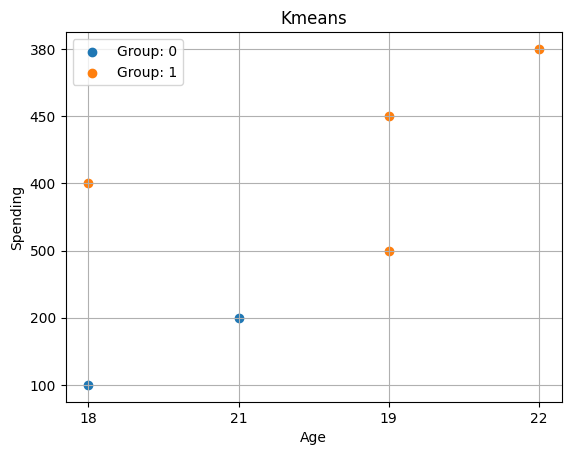

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,LinearRegression 


customer={
    "Name":["Pranav","Yashashwai","Shreyas","Ayush","Pragati","Sneha"],
    "Age":["18","21","19","18","19","22"],
    "Spending":["100","200","500","400","450","380"]
}
df=pd.DataFrame(customer)
x=df[['Age','Spending']].astype(int)
# print(df)
model=KMeans(n_clusters=2,random_state=43,n_init=10)
df['group']=model.fit_predict(x)
print(len(df["group"].unique()))

for group in df["group"].unique():
    print(group)
    group_data=df[df["group"]==group]
    print(group_data)
    plt.scatter(group_data['Age'],group_data['Spending'],label=f"Group: {group}")

plt.xlabel("Age")
plt.ylabel("Spending")
plt.title("Kmeans")
plt.legend()
plt.grid(True)
plt.show()

Name error found
[[-1.46385011 -1.46385011 -1.46385011 -1.30855981]
 [-0.87831007 -0.29277002 -0.87831007 -0.99450545]
 [-0.29277002 -0.87831007 -0.29277002 -0.36639675]
 [ 0.29277002  0.29277002  0.29277002  0.26171196]
 [ 0.87831007  0.87831007  0.87831007  0.88982067]
 [ 1.46385011  1.46385011  1.46385011  1.51792938]]
       PCA1      PCA2
0 -2.849388 -0.088865
1 -1.528716  0.525607
2 -0.908668 -0.493243
3  0.569878  0.017773
4  1.762257  0.018834
5  2.954637  0.019894
Variance captured by each PCA component
[97.67  2.2 ]


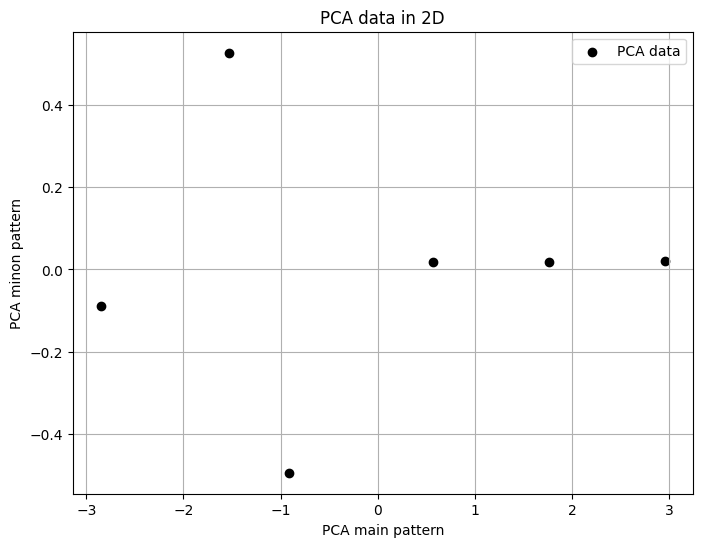

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition  import PCA

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

data={
    "Age":[30,40,50,60,70,80],
    "Income":[55000,65000,60000,70000,75000,80000],
    "Spending":[70,80,90,100,110,120],
    "Saving":[7000 ,8000,10000,12000,14000,16000 ]
}
df=pd.DataFrame(data)
df
model=StandardScaler()
try:
    scaled_data=model.fit_transform(df)
except NameError:
    print("Name error found")
print(scaled_data)
pca=PCA(n_components=2)
pca_result=pca.fit_transform(scaled_data)

pca_df=pd.DataFrame(pca_result,columns=["PCA1","PCA2"])
print(pca_df)
explained_variance=pca.explained_variance_ratio_
print("Variance captured by each PCA component")
print(np.round(explained_variance*100,2))
plt.figure(figsize=(8,6))
plt.scatter(pca_df["PCA1"],pca_df["PCA2"],color="black",label=f"PCA data")
plt.legend()
plt.xlabel("PCA main pattern")
plt.ylabel("PCA minon pattern")
plt.title("PCA data in 2D")
plt.grid()
plt.show()


In [ ]:
import requests
from bs4 import BeautifulSoup
import json

url = "https://gamenation.in"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')

games = []

# Find all game elements
for item in soup.find_all(['article', 'div', 'li']):
    name = item.find(['h1', 'h2', 'h3', 'h4', 'a'])
    desc = item.find('p')
    
    if name:
        game = {
            'name': name.get_text(strip=True),
            'info': desc.get_text(strip=True) if desc else ''
        }
        games.append(game)

# Save to JSON
with open('games.json', 'w', encoding='utf-8') as f:
    json.dump({'games': games}, f, indent=2, ensure_ascii=False)

print(f"Found {len(games)} games - saved to games.json")

Found 162 games - saved to games.json


: 